In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
from src.db import get_engine

In [3]:
engine = get_engine()

In [4]:
query = """
SELECT *
FROM
credit_card_transactions;
"""

In [5]:
df = pd.read_sql(query, engine)

In [6]:
x = df.drop(columns=["class"])
y = df["class"]

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

x shape: (284807, 30)
y shape: (284807,)


In [7]:
print(y.value_counts())

class
0    284315
1       492
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
print("Training set:", x_train.shape)
print("Testing set :", x_test.shape)

Training set: (227845, 30)
Testing set : (56962, 30)


In [11]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Testing class distribution:
class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
sc = StandardScaler()

In [14]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [15]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(227845, 30)
(56962, 30)


In [16]:
from sklearn.naive_bayes import GaussianNB

In [17]:
gnb = GaussianNB()
gnb.fit(x_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[227451., 394.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[1.,0.]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 30)","[[ 0. , 0. ,-0. ,...,-0. ,-0. ,-0. ], [-0.25,-2.4 , 2.18,..., 0.39, 0.24, 0.15]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 30)","[[ 1. , 0.97, 0.98,..., 0.98, 1. , 1. ], [ 1.02,12.17, 6.81,...,11.23, 2.88, 1.09]]"


In [18]:
y_pred = gnb.predict(x_test_scaled)
y_prob = gnb.predict_proba(x_test_scaled)[:, 1]

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

In [20]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.9764
Precision: 0.0588
Recall   : 0.8469
F1 Score : 0.1099
ROC AUC  : 0.9632


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.85      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [22]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55535  1329]
 [   15    83]]


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

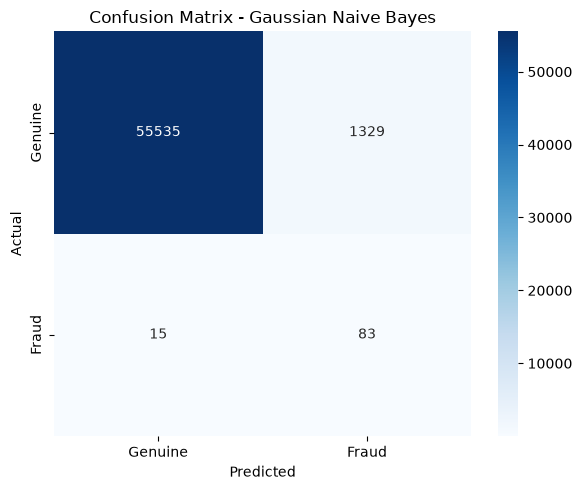

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

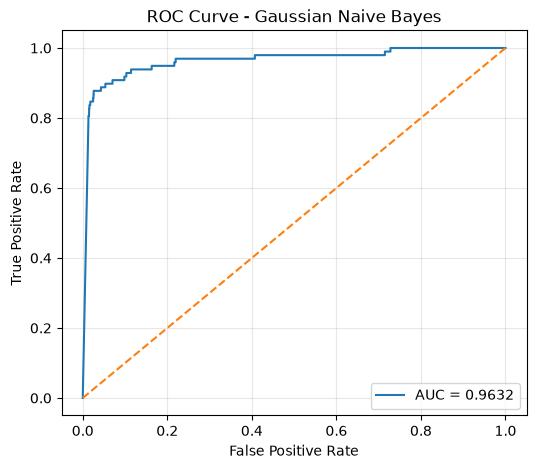

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian Naive Bayes")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
from sklearn.cluster import KMeans

In [27]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(x_train_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 30)","[[-0

In [28]:
train_clusters = kmeans.predict(x_train_scaled)
test_clusters = kmeans.predict(x_test_scaled)

In [29]:

cluster_df = pd.DataFrame({
    "Cluster": train_clusters,
    "Actual": y_train.values
})

In [30]:
print(cluster_df.groupby("Cluster")["Actual"].value_counts())

Cluster  Actual
0        0         123557
         1            229
1        0         103894
         1            165
Name: count, dtype: int64


In [31]:
distances = kmeans.transform(x_test_scaled)
min_distances = distances.min(axis=1)
print(min_distances[:10])

[ 3.68017194  6.73639968 10.18575071  2.59540704  6.83250123  2.84601446
  4.77066627  3.12952272  3.32961554  3.41248777]


In [32]:
import numpy as np

In [33]:
fraud_ratio = y.mean()

threshold = np.percentile(
    min_distances,
    100 * (1 - fraud_ratio)
)

y_pred_kmeans = (min_distances > threshold).astype(int)

In [34]:
print("Predicted frauds:", y_pred_kmeans.sum())
print("Actual frauds   :", y_test.sum())

Predicted frauds: 99
Actual frauds   : 98


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [48]:
kmeans_accuracy = accuracy_score(y_test, y_pred_kmeans)
kmeans_precision = precision_score(y_test, y_pred_kmeans)
kmeans_recall = recall_score(y_test, y_pred_kmeans)
kmeans_f1 = f1_score(y_test, y_pred_kmeans)
kmeans_auc = roc_auc_score(y_test, min_distances)

In [49]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_kmeans):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_kmeans):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_kmeans):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_kmeans):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, min_distances):.4f}")

Accuracy : 0.9974
Precision: 0.2424
Recall   : 0.2449
F1 Score : 0.2437
ROC AUC  : 0.9582


In [37]:
print(classification_report(y_test, y_pred_kmeans))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.24      0.24        98

    accuracy                           1.00     56962
   macro avg       0.62      0.62      0.62     56962
weighted avg       1.00      1.00      1.00     56962



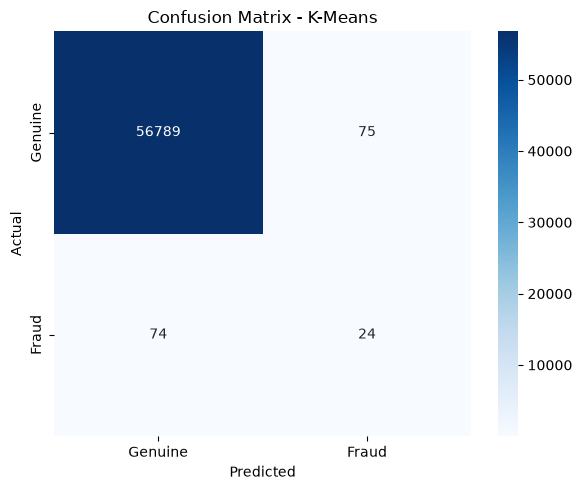

In [38]:
cm = confusion_matrix(y_test, y_pred_kmeans)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title("Confusion Matrix - K-Means")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

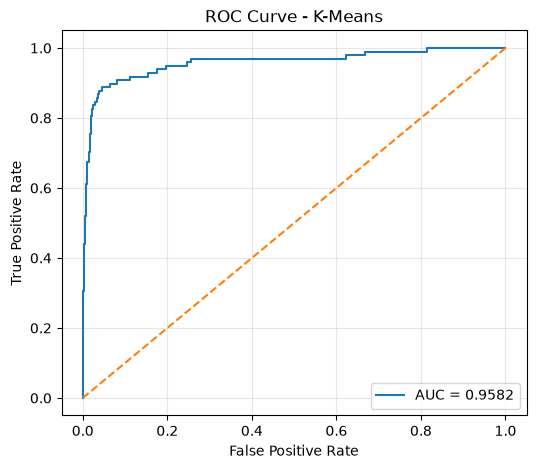

In [39]:
fpr, tpr, _ = roc_curve(y_test, min_distances)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, min_distances):.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - K-Means")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
param_grid = {"var_smoothing": np.logspace(0, -9, num=100)}

In [42]:
grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [43]:
grid.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-09])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hi

In [44]:
print("Best parameter:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameter: {'var_smoothing': np.float64(1.0)}
Best CV F1: 0.19213285138486466


In [45]:
best_gnb = grid.best_estimator_

In [46]:
y_pred = best_gnb.predict(x_test_scaled)

In [50]:
gnb_accuracy = accuracy_score(y_test, y_pred)
gnb_precision = precision_score(y_test, y_pred)
gnb_recall = recall_score(y_test, y_pred)
gnb_f1 = f1_score(y_test, y_pred)
gnb_auc = roc_auc_score(y_test, y_prob)

In [51]:
print(f"Accuracy : {gnb_accuracy:.4f}")
print(f"Precision: {gnb_precision:.4f}")
print(f"Recall   : {gnb_recall:.4f}")
print(f"F1 Score : {gnb_f1:.4f}")
print(f"ROC AUC  : {gnb_auc:.4f}")

Accuracy : 0.9879
Precision: 0.1051
Recall   : 0.8061
F1 Score : 0.1859
ROC AUC  : 0.9632


In [52]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes", "K-Means"],
    "Accuracy": [gnb_accuracy, kmeans_accuracy],
    "Precision": [gnb_precision, kmeans_precision],
    "Recall": [gnb_recall, kmeans_recall],
    "F1-Score": [gnb_f1, kmeans_f1],
    "ROC-AUC": [gnb_auc, kmeans_auc]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gaussian Naive Bayes,0.987852,0.105053,0.806122,0.185882,0.963248
1,K-Means,0.997384,0.242424,0.244898,0.243655,0.958226


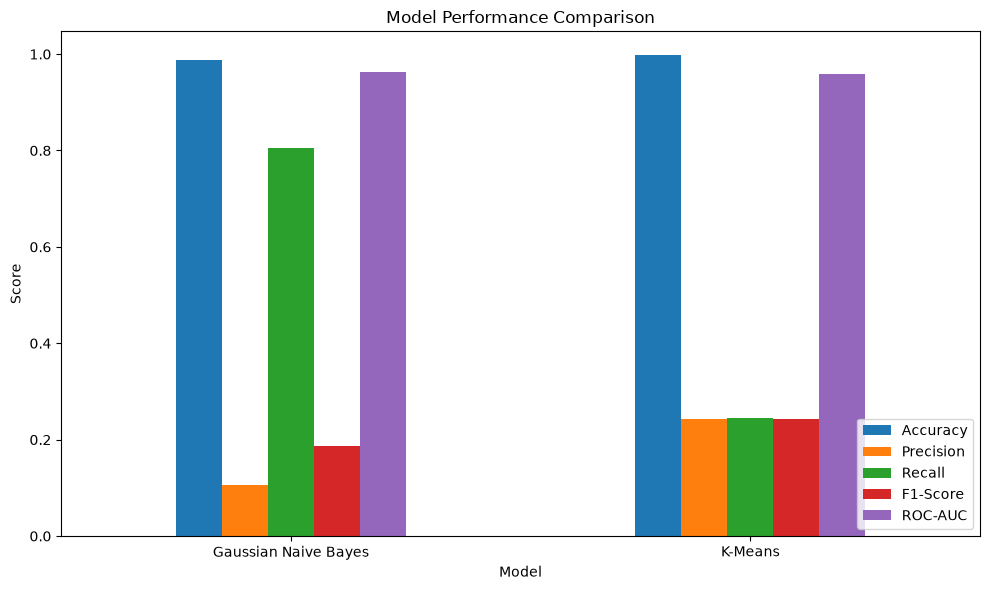

In [53]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [55]:
import joblib

joblib.dump(best_gnb, "../models/gaussian_nb_model.pkl")
joblib.dump(sc, "../models/scaler.pkl")
joblib.dump(kmeans, "../models/kmeans_model.pkl")

['../models/kmeans_model.pkl']